Attempting to fetch real S&P 500 data...
Could not fetch real data ('Adj Close'), using synthetic data instead...
Generated 2500 days of synthetic volatility data
Low volatility periods: 1915 days
High volatility periods: 585 days
S&P 500 BIMODAL VOLATILITY AR MODEL
Model fitted successfully!
Regime 1 (Low Vol) Mean: 0.1247
Regime 2 (High Vol) Mean: 0.2242
Transition Matrix:
[[0.95129698 0.04870302]
 [0.15081967 0.84918033]]

Generating predictions...

FORECAST SUMMARY (Next 30 Days)

Current Volatility: 0.1183
Current Regime: Low Volatility

Predicted Volatility (Annualized):
  Day  1: Mean=0.1293, 90% CI=[0.1022, 0.1557]
  Day  5: Mean=0.1318, 90% CI=[0.0860, 0.1802]
  Day 10: Mean=0.1302, 90% CI=[0.0710, 0.1860]
  Day 20: Mean=0.1274, 90% CI=[0.0525, 0.2012]
  Day 30: Mean=0.1247, 90% CI=[0.0360, 0.2131]

Regime Probabilities:
  Day  1: P(Low Vol)=0.951, P(High Vol)=0.049
  Day  5: P(Low Vol)=0.836, P(High Vol)=0.164
  Day 10: P(Low Vol)=0.782, P(High Vol)=0.218
  Day 20: P(Low Vol)

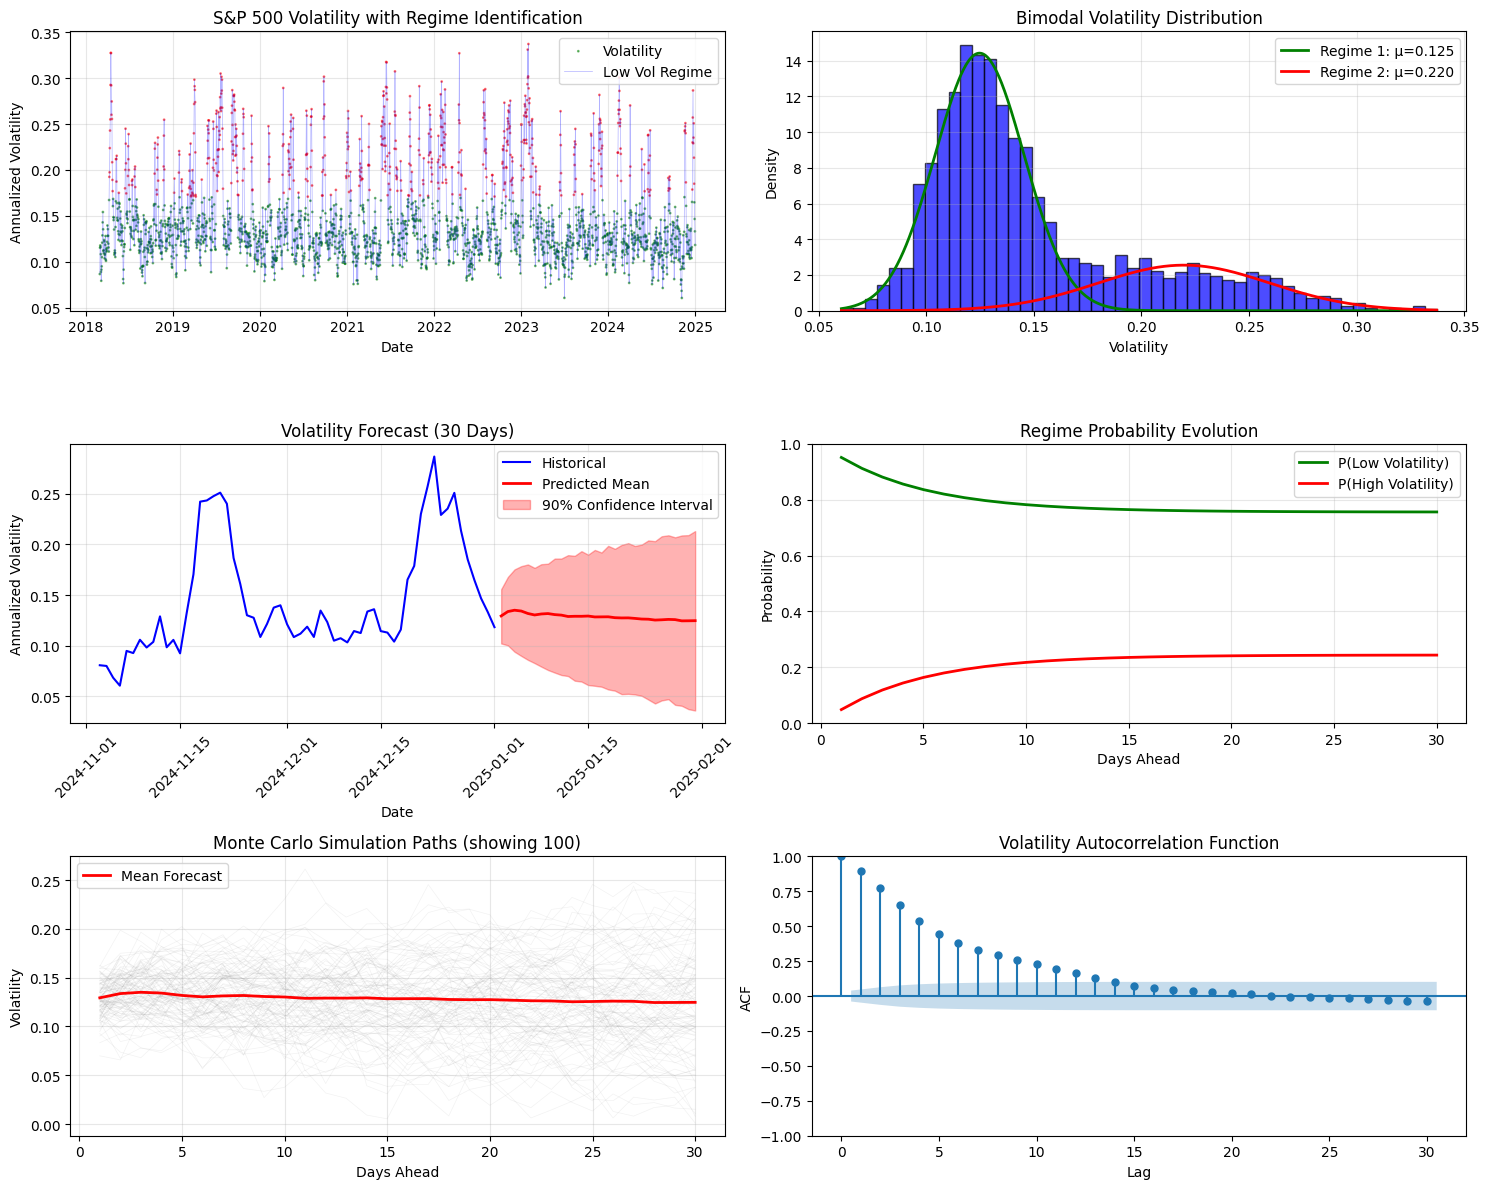


MODEL DIAGNOSTICS

Normality Test (should reject for bimodal):
  p-value: 0.000000 (Reject H0 - Data is not normal)

Likelihood Ratio Test (1 vs 2 regimes):
  LR Statistic: 1234.39
  p-value: 0.000000 (Evidence for 2 regimes)

Model training complete! Check sp500_volatility_analysis.png for visualizations.


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.mixture import GaussianMixture
import warnings
warnings.filterwarnings('ignore')

# Generate synthetic S&P 500-like volatility data with regime switching
def generate_synthetic_volatility_data(n_days=2500):
    """Generate synthetic volatility data that mimics S&P 500 bimodal behavior"""
    np.random.seed(42)
    
    # Parameters for two volatility regimes
    low_vol_mean = 0.12  # 12% annual volatility (calm market)
    high_vol_mean = 0.25  # 25% annual volatility (stressed market)
    low_vol_std = 0.03
    high_vol_std = 0.08
    
    # Transition probabilities
    prob_stay_low = 0.95  # High probability of staying in low vol
    prob_stay_high = 0.85  # Lower probability of staying in high vol
    
    volatility = []
    regimes = []
    current_regime = 0  # Start in low volatility
    
    for _ in range(n_days):
        # Determine regime
        if current_regime == 0:  # Low volatility
            if np.random.random() > prob_stay_low:
                current_regime = 1
        else:  # High volatility
            if np.random.random() > prob_stay_high:
                current_regime = 0
        
        regimes.append(current_regime)
        
        # Generate volatility based on regime with AR component
        if current_regime == 0:
            base_vol = np.random.normal(low_vol_mean, low_vol_std)
        else:
            base_vol = np.random.normal(high_vol_mean, high_vol_std)
        
        # Add AR(1) component for persistence
        if len(volatility) > 0:
            vol = 0.7 * volatility[-1] + 0.3 * base_vol + np.random.normal(0, 0.01)
        else:
            vol = base_vol
        
        # Ensure positive volatility
        vol = max(0.02, vol)
        volatility.append(vol)
    
    # Create DataFrame
    dates = pd.date_range(end='2025-01-01', periods=n_days, freq='D')
    data = pd.DataFrame({
        'Volatility': volatility,
        'Regime': regimes
    }, index=dates)
    
    # Generate synthetic returns based on volatility
    daily_vol = np.array(volatility) / np.sqrt(252)
    returns = np.random.normal(0.0003, daily_vol)  # Small positive drift
    data['Returns'] = returns
    data['Squared_Returns'] = returns**2
    data['Log_Volatility'] = np.log(data['Volatility'])
    
    print(f"Generated {n_days} days of synthetic volatility data")
    print(f"Low volatility periods: {(np.array(regimes) == 0).sum()} days")
    print(f"High volatility periods: {(np.array(regimes) == 1).sum()} days")
    
    return data

# Fetch S&P 500 data (with fallback to synthetic)
def fetch_sp500_data(start_date='2015-01-01', end_date='2025-01-01'):
    """Fetch S&P 500 data and calculate returns and volatility"""
    print("Attempting to fetch real S&P 500 data...")
    try:
        import yfinance as yf
        sp500 = yf.download('^GSPC', start=start_date, end=end_date, progress=False)
        
        if sp500.empty:
            raise ValueError("No data retrieved")
            
        # Calculate returns
        sp500['Returns'] = sp500['Adj Close'].pct_change()
        
        # Calculate realized volatility (20-day rolling window)
        sp500['Volatility'] = sp500['Returns'].rolling(window=20).std() * np.sqrt(252)
        
        # Alternative volatility measures
        sp500['Squared_Returns'] = sp500['Returns']**2
        sp500['Log_Volatility'] = np.log(sp500['Volatility'].replace(0, np.nan))
        
        result = sp500.dropna()
        if result.empty:
            raise ValueError("No valid data after processing")
        return result
    except Exception as e:
        print(f"Could not fetch real data ({e}), using synthetic data instead...")
        return generate_synthetic_volatility_data()

# Bimodal Markov Regime-Switching AR Model
class BimodalARModel:
    def __init__(self, ar_order=5):
        self.ar_order = ar_order
        self.regime1_params = None
        self.regime2_params = None
        self.transition_matrix = None
        self.current_regime = None
        self.gmm = None
        
    def identify_regimes(self, data):
        """Identify volatility regimes using Gaussian Mixture Model"""
        # Reshape for GMM
        X = data.reshape(-1, 1)
        
        # Fit GMM with 2 components for bimodal distribution
        self.gmm = GaussianMixture(n_components=2, random_state=42)
        self.gmm.fit(X)
        
        # Predict regimes
        regimes = self.gmm.predict(X)
        
        # Ensure regime 0 is low volatility, regime 1 is high volatility
        if self.gmm.means_[0] > self.gmm.means_[1]:
            regimes = 1 - regimes
            self.gmm.means_ = self.gmm.means_[::-1]
            self.gmm.covariances_ = self.gmm.covariances_[::-1]
            self.gmm.weights_ = self.gmm.weights_[::-1]
        
        return regimes
    
    def estimate_transition_matrix(self, regimes):
        """Estimate Markov transition probabilities"""
        transitions = np.zeros((2, 2))
        
        for i in range(len(regimes) - 1):
            transitions[regimes[i], regimes[i+1]] += 1
        
        # Normalize to get probabilities
        self.transition_matrix = transitions / transitions.sum(axis=1, keepdims=True)
        return self.transition_matrix
    
    def fit_ar_model(self, data, regime_mask):
        """Fit AR model for specific regime"""
        regime_data = data[regime_mask]
        
        if len(regime_data) <= self.ar_order:
            return None
        
        # Create lagged features
        X = []
        y = []
        for i in range(self.ar_order, len(regime_data)):
            X.append(regime_data[i-self.ar_order:i])
            y.append(regime_data[i])
        
        X = np.array(X)
        y = np.array(y)
        
        # Fit linear regression
        coeffs = np.linalg.lstsq(X, y, rcond=None)[0]
        residual_std = np.std(y - X @ coeffs)
        
        return {'coeffs': coeffs, 'std': residual_std, 'mean': np.mean(regime_data)}
    
    def fit(self, data):
        """Fit the complete bimodal AR model"""
        # Identify regimes
        self.regimes = self.identify_regimes(data)
        
        # Estimate transition matrix
        self.estimate_transition_matrix(self.regimes)
        
        # Fit AR models for each regime
        self.regime1_params = self.fit_ar_model(data, self.regimes == 0)
        self.regime2_params = self.fit_ar_model(data, self.regimes == 1)
        
        # Set initial regime
        self.current_regime = self.regimes[-1]
        
        print(f"Model fitted successfully!")
        print(f"Regime 1 (Low Vol) Mean: {self.regime1_params['mean']:.4f}")
        print(f"Regime 2 (High Vol) Mean: {self.regime2_params['mean']:.4f}")
        print(f"Transition Matrix:\n{self.transition_matrix}")
        
    def predict_next_regime(self):
        """Predict next regime based on transition probabilities"""
        if self.current_regime == 0:
            prob_stay = self.transition_matrix[0, 0]
        else:
            prob_stay = self.transition_matrix[1, 1]
        
        # Sample next regime
        if np.random.random() < prob_stay:
            return self.current_regime
        else:
            return 1 - self.current_regime
    
    def predict(self, history, n_steps=30, n_simulations=1000):
        """Generate predictions with uncertainty"""
        predictions = []
        
        for _ in range(n_simulations):
            sim_history = list(history[-self.ar_order:])
            sim_regimes = []
            sim_predictions = []
            current_reg = self.current_regime
            
            for _ in range(n_steps):
                # Determine regime
                current_reg = self.predict_next_regime() if _ > 0 else current_reg
                sim_regimes.append(current_reg)
                
                # Get appropriate model parameters
                if current_reg == 0:
                    params = self.regime1_params
                else:
                    params = self.regime2_params
                
                # Make prediction
                if params and len(sim_history) >= self.ar_order:
                    ar_input = np.array(sim_history[-self.ar_order:])
                    pred_mean = ar_input @ params['coeffs']
                    pred_value = pred_mean + np.random.normal(0, params['std'])
                    # Ensure non-negative volatility
                    pred_value = max(0.001, pred_value)
                else:
                    pred_value = params['mean'] if params else 0.15
                
                sim_predictions.append(pred_value)
                sim_history.append(pred_value)
            
            predictions.append(sim_predictions)
        
        predictions = np.array(predictions)
        
        # Calculate statistics
        mean_pred = np.mean(predictions, axis=0)
        lower_bound = np.percentile(predictions, 5, axis=0)
        upper_bound = np.percentile(predictions, 95, axis=0)
        
        # Calculate regime probabilities
        regime_probs = self.calculate_regime_probabilities(n_steps)
        
        return {
            'mean': mean_pred,
            'lower': lower_bound,
            'upper': upper_bound,
            'all_simulations': predictions,
            'regime_probs': regime_probs
        }
    
    def calculate_regime_probabilities(self, n_steps):
        """Calculate probability of being in each regime over time"""
        # Initial state vector
        if self.current_regime == 0:
            state = np.array([1.0, 0.0])
        else:
            state = np.array([0.0, 1.0])
        
        probs = []
        for _ in range(n_steps):
            state = state @ self.transition_matrix
            probs.append(state.copy())
        
        return np.array(probs)

# Visualization functions
def plot_volatility_analysis(data, model, predictions):
    """Create comprehensive volatility analysis plots"""
    fig = plt.figure(figsize=(15, 12))
    
    # Plot 1: Historical Volatility with Regimes
    ax1 = plt.subplot(3, 2, 1)
    volatility = data['Volatility'].values
    dates = data.index
    
    # Color by regime
    regime_colors = ['green' if r == 0 else 'red' for r in model.regimes]
    ax1.scatter(dates[-len(model.regimes):], volatility[-len(model.regimes):], 
                c=regime_colors, alpha=0.5, s=1)
    ax1.plot(dates, volatility, 'b-', alpha=0.3, linewidth=0.5)
    ax1.set_title('S&P 500 Volatility with Regime Identification')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Annualized Volatility')
    ax1.legend(['Volatility', 'Low Vol Regime', 'High Vol Regime'], loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Volatility Distribution (Bimodal)
    ax2 = plt.subplot(3, 2, 2)
    ax2.hist(volatility, bins=50, alpha=0.7, density=True, color='blue', edgecolor='black')
    
    # Overlay GMM components
    x_range = np.linspace(volatility.min(), volatility.max(), 1000)
    for i in range(2):
        mean = model.gmm.means_[i, 0]
        std = np.sqrt(model.gmm.covariances_[i, 0, 0])
        weight = model.gmm.weights_[i]
        ax2.plot(x_range, weight * stats.norm.pdf(x_range, mean, std), 
                'r-' if i == 1 else 'g-', linewidth=2, 
                label=f'Regime {i+1}: μ={mean:.3f}')
    
    ax2.set_title('Bimodal Volatility Distribution')
    ax2.set_xlabel('Volatility')
    ax2.set_ylabel('Density')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Predictions
    ax3 = plt.subplot(3, 2, 3)
    
    # Historical data
    n_historical = 60
    historical_vol = volatility[-n_historical:]
    historical_dates = dates[-n_historical:]
    
    # Future dates
    last_date = dates[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), 
                                  periods=len(predictions['mean']), freq='D')
    
    # Plot historical
    ax3.plot(historical_dates, historical_vol, 'b-', label='Historical', linewidth=1.5)
    
    # Plot predictions
    ax3.plot(future_dates, predictions['mean'], 'r-', label='Predicted Mean', linewidth=2)
    ax3.fill_between(future_dates, predictions['lower'], predictions['upper'], 
                     alpha=0.3, color='red', label='90% Confidence Interval')
    
    ax3.set_title('Volatility Forecast (30 Days)')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Annualized Volatility')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.tick_params(axis='x', rotation=45)
    
    # Plot 4: Regime Transition Probabilities
    ax4 = plt.subplot(3, 2, 4)
    days_ahead = np.arange(1, len(predictions['regime_probs']) + 1)
    ax4.plot(days_ahead, predictions['regime_probs'][:, 0], 'g-', 
             label='P(Low Volatility)', linewidth=2)
    ax4.plot(days_ahead, predictions['regime_probs'][:, 1], 'r-', 
             label='P(High Volatility)', linewidth=2)
    ax4.set_title('Regime Probability Evolution')
    ax4.set_xlabel('Days Ahead')
    ax4.set_ylabel('Probability')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim([0, 1])
    
    # Plot 5: Simulation Paths
    ax5 = plt.subplot(3, 2, 5)
    # Plot sample paths
    n_paths_to_show = 100
    for i in range(min(n_paths_to_show, len(predictions['all_simulations']))):
        ax5.plot(days_ahead, predictions['all_simulations'][i], 
                'gray', alpha=0.1, linewidth=0.5)
    ax5.plot(days_ahead, predictions['mean'], 'r-', linewidth=2, label='Mean Forecast')
    ax5.set_title(f'Monte Carlo Simulation Paths (showing {n_paths_to_show})')
    ax5.set_xlabel('Days Ahead')
    ax5.set_ylabel('Volatility')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # Plot 6: Autocorrelation
    ax6 = plt.subplot(3, 2, 6)
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(volatility, lags=30, ax=ax6, alpha=0.05)
    ax6.set_title('Volatility Autocorrelation Function')
    ax6.set_xlabel('Lag')
    ax6.set_ylabel('ACF')
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/sp500_volatility_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig

# Main execution
def main():
    # Fetch data
    sp500_data = fetch_sp500_data()
    volatility = sp500_data['Volatility'].values
    
    print("="*50)
    print("S&P 500 BIMODAL VOLATILITY AR MODEL")
    print("="*50)
    
    # Create and fit the model
    model = BimodalARModel(ar_order=5)
    model.fit(volatility)
    
    # Generate predictions
    print("\nGenerating predictions...")
    predictions = model.predict(volatility, n_steps=30, n_simulations=1000)
    
    # Display prediction summary
    print("\n" + "="*50)
    print("FORECAST SUMMARY (Next 30 Days)")
    print("="*50)
    
    print(f"\nCurrent Volatility: {volatility[-1]:.4f}")
    print(f"Current Regime: {'Low Volatility' if model.current_regime == 0 else 'High Volatility'}")
    
    print("\nPredicted Volatility (Annualized):")
    for i, day in enumerate([1, 5, 10, 20, 30]):
        if day <= len(predictions['mean']):
            idx = day - 1
            print(f"  Day {day:2d}: Mean={predictions['mean'][idx]:.4f}, "
                  f"90% CI=[{predictions['lower'][idx]:.4f}, {predictions['upper'][idx]:.4f}]")
    
    print("\nRegime Probabilities:")
    for i, day in enumerate([1, 5, 10, 20, 30]):
        if day <= len(predictions['regime_probs']):
            idx = day - 1
            print(f"  Day {day:2d}: P(Low Vol)={predictions['regime_probs'][idx, 0]:.3f}, "
                  f"P(High Vol)={predictions['regime_probs'][idx, 1]:.3f}")
    
    # Create visualizations
    print("\nGenerating visualizations...")
    plot_volatility_analysis(sp500_data, model, predictions)
    
    # Statistical tests
    print("\n" + "="*50)
    print("MODEL DIAGNOSTICS")
    print("="*50)
    
    # Test for bimodality
    from scipy import stats
    dip_stat, dip_pval = stats.normaltest(volatility)
    print(f"\nNormality Test (should reject for bimodal):")
    print(f"  p-value: {dip_pval:.6f} {'(Reject H0 - Data is not normal)' if dip_pval < 0.05 else '(Fail to reject H0)'}")
    
    # Likelihood ratio test for number of regimes
    gmm_1 = GaussianMixture(n_components=1, random_state=42)
    gmm_1.fit(volatility.reshape(-1, 1))
    
    lr_statistic = 2 * (model.gmm.score(volatility.reshape(-1, 1)) * len(volatility) - 
                        gmm_1.score(volatility.reshape(-1, 1)) * len(volatility))
    lr_pval = 1 - stats.chi2.cdf(lr_statistic, df=3)  # df = difference in parameters
    
    print(f"\nLikelihood Ratio Test (1 vs 2 regimes):")
    print(f"  LR Statistic: {lr_statistic:.2f}")
    print(f"  p-value: {lr_pval:.6f} {'(Evidence for 2 regimes)' if lr_pval < 0.05 else '(No strong evidence for 2 regimes)'}")
    
    print("\n" + "="*50)
    print("Model training complete! Check sp500_volatility_analysis.png for visualizations.")
    
    return model, predictions, sp500_data

if __name__ == "__main__":
    model, predictions, data = main()